In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [86]:
data = pd.read_csv(f"../data/processed/analysis_delivery.csv")

date_cols = [ "order_purchase_timestamp", "order_approved_at","order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]

data[date_cols] = data[date_cols].apply(pd.to_datetime)

EDA

In [87]:
data.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,on_time_flag,...,purchase_weekday,customer_state,review_score,product_id,seller_id,price,freight_value,product_category_name,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,-8,1,...,Monday,SP,4.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,utilidades_domesticas,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,-6,1,...,Tuesday,BA,4.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumaria,SP,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,-18,1,...,Wednesday,GO,5.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,automotivo,SP,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,-13,1,...,Saturday,RN,5.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,pet_shop,MG,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,-10,1,...,Tuesday,SP,5.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,papelaria,SP,stationery


In [88]:
data.shape

(110816, 24)

The analysis_delivery dataset contains 110,816 orders and 24 variables, providing sufficient observations for exploratory analysis.

In [89]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 110816 entries, 0 to 110815
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110816 non-null  str           
 1   customer_id                    110816 non-null  str           
 2   order_status                   110816 non-null  str           
 3   order_purchase_timestamp       110816 non-null  datetime64[us]
 4   order_approved_at              110816 non-null  datetime64[us]
 5   order_delivered_carrier_date   110816 non-null  datetime64[us]
 6   order_delivered_customer_date  110816 non-null  datetime64[us]
 7   order_estimated_delivery_date  110816 non-null  datetime64[us]
 8   delivery_delay_days            110816 non-null  int64         
 9   on_time_flag                   110816 non-null  int64         
 10  processing_days                110816 non-null  int64         
 11  shipping_da

In [90]:
data.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
delivery_delay_days              0
on_time_flag                     0
processing_days                  0
shipping_days                    0
basket_size                      0
purchase_month                   0
purchase_weekday                 0
customer_state                   0
review_score                     0
product_id                       0
seller_id                        0
price                            0
freight_value                    0
product_category_name            0
seller_state                     0
product_category_name_english    0
dtype: int64

No missing values remain in the dataset. The data cleaning process successfully handled all incomplete records, ensuring data quality for subsequent analysis.

In [91]:
data.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,on_time_flag,processing_days,shipping_days,basket_size,purchase_month,review_score,price,freight_value
count,110816,110816,110816,110816,110816,110816.000000,110816.000000,110816.000000,110816.000000,110816.000000,110816.000000,110816.000000,110816.000000,110816.000000
mean,2018-01-01 18:30:54.325187,2018-01-02 05:02:16.275628,2018-01-05 01:23:07.337568,2018-01-14 05:56:50.421960,2018-01-25 14:01:56.430840,-12.033479,0.934197,2.800399,8.737773,1.397885,6.030970,4.043315,119.808854,19.937555
min,2016-09-15 12:16:00,2016-09-15 12:16:00,2016-10-08 10:34:00,2016-10-11 13:46:00,2016-10-04 00:00:00,-147.000000,0.000000,0.000000,0.000000,1.000000,1.000000,-1.000000,0.850000,0.000000
25%,2017-09-14 18:12:15,2017-09-15 02:10:00,2017-09-18 20:32:00,2017-09-26 18:25:00,2017-10-05 00:00:00,-17.000000,1.000000,1.000000,4.000000,1.000000,3.000000,4.000000,39.900000,13.070000
50%,2018-01-20 17:44:00,2018-01-22 13:44:00,2018-01-24 16:01:00,2018-02-02 17:47:00,2018-02-16 00:00:00,-13.000000,1.000000,2.000000,7.000000,1.000000,6.000000,5.000000,74.900000,16.250000
75%,2018-05-04 23:18:00,2018-05-05 12:13:00,2018-05-08 13:14:30,2018-05-15 18:04:00,2018-05-28 00:00:00,-7.000000,1.000000,4.000000,11.000000,1.000000,8.000000,5.000000,133.900000,21.150000
max,2018-08-29 15:00:00,2018-08-29 15:10:00,2018-09-11 19:48:00,2018-10-17 13:22:00,2018-10-25 00:00:00,188.000000,1.000000,125.000000,205.000000,21.000000,12.000000,5.000000,6735.000000,409.680000
std,NaN,NaN,NaN,NaN,NaN,10.157723,0.247938,3.623257,8.605489,1.126195,3.232279,1.412094,181.970642,15.675722


- Approximately 93.4% of orders were delivered on or before the estimated delivery date, indicating strong overall delivery performance. 
- The remaining delayed orders should be further analyzed to identify operational bottlenecks and opportunities for improvement.

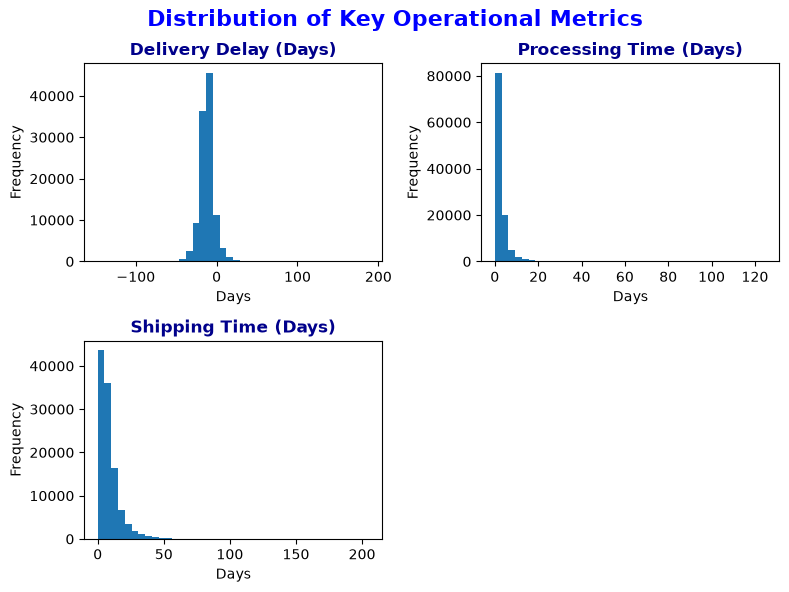

In [92]:
fig, axes = plt.subplots(2,2, figsize = (8,6))

columns = ["delivery_delay_days", "processing_days", "shipping_days"]
titles = ["Delivery Delay (Days)", "Processing Time (Days)", "Shipping Time (Days)"]

for ax, col, title in zip(axes.flat, columns, titles):
    ax.hist(data[col], bins = 40)
    ax.set_title(title, color = "darkblue", fontweight = "bold")
    ax.set_xlabel("Days")
    ax.set_ylabel("Frequency")

axes[1, 1].axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.suptitle("Distribution of Key Operational Metrics", fontsize=16, fontweight="bold", color = "blue")
plt.show()

- Most orders ware delivered on time or earlier than the estimated delivery rate.
- Sellers generally processed and handed over order to carrier quickly.
- Althought most shipments were completed within a resonable timeframe, a small number experienced considerably longer shipments time, potentially leading to delivery delays.

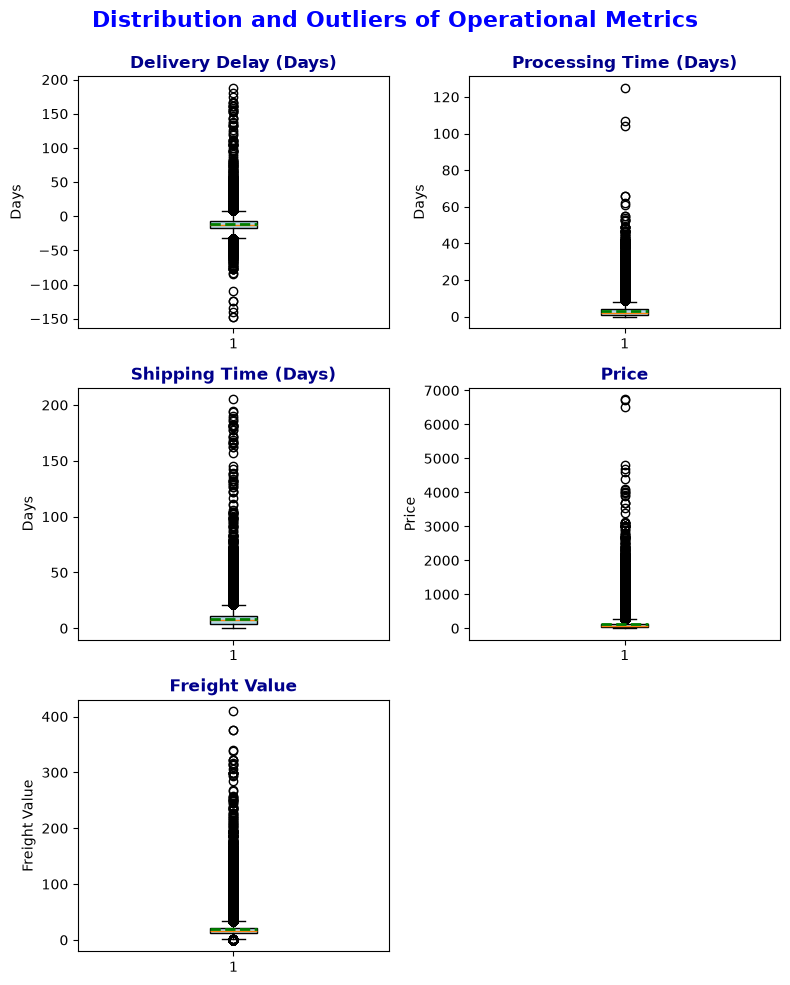

In [93]:
fig, axes = plt.subplots(3,2, figsize = (8,10))

columns = ["delivery_delay_days", "processing_days", "shipping_days", "price", "freight_value"]
titles = ["Delivery Delay (Days)", "Processing Time (Days)", "Shipping Time (Days)", "Price", "Freight Value"]
ylabels = ["Days","Days", "Days", "Price","Freight Value"]

for ax, col, title, ylabel in zip(axes.flat, columns, titles, ylabels):
    ax.boxplot(data[col].dropna(), orientation="vertical",patch_artist=True, boxprops=dict(facecolor="lightblue"), showmeans=True, meanline=True,meanprops=dict(color="green", linewidth=2))
    ax.set_title(title, color = "darkblue", fontweight = "bold")
    ax.set_ylabel(ylabel)

axes[2, 1].axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.suptitle("Distribution and Outliers of Operational Metrics", fontsize = 16, fontweight = "bold", color = "blue")
plt.show()

- Most observations are concentrated within a relatively narrow range, indicating consistent operational performance for the majority of orders.
- Delivery delay values are primarily negative, suggesting that most orders were delivered on or before the estimated delivery date.
- A small number of orders exhibit exceptionally long processing and shipping times, creating noticeable outliers and pulling the mean above the median.
- Price and freight value show substantial variability, with several high-value outliers compared with the majority of orders.

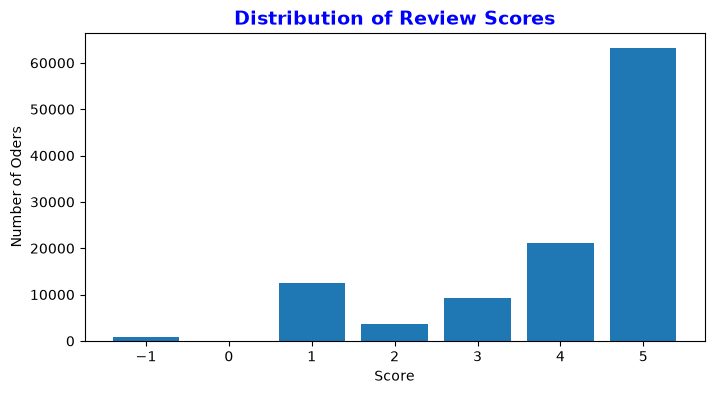

In [94]:
score_counts = data["review_score"].value_counts().sort_index()

plt.figure(figsize = (8,4))
plt.bar(score_counts.index, score_counts.values)
plt.xlabel("Score")
plt.ylabel("Number of Oders")
plt.title("Distribution of Review Scores", fontweight="bold", color = "blue", fontsize = 14)
plt.show()

- A small number of orders did not receive a customer review  (Score = -1).
- Among reviewed orders, 5-star ratings dominate, indicating generally positive customer satisfaction.
- Most customers provided positive ratings (4–5 stars), while low ratings (1–2 stars) are relatively uncommon.

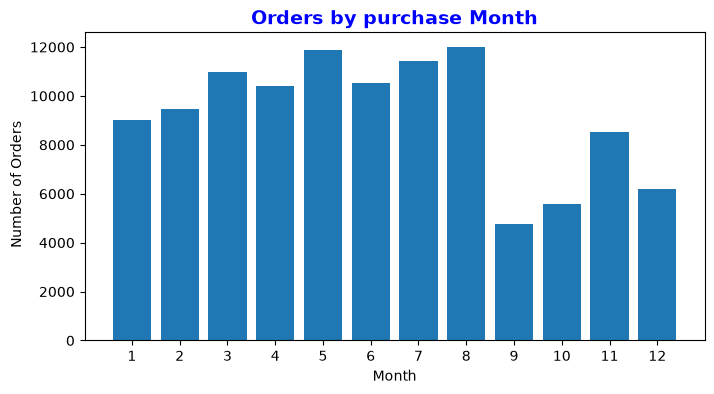

In [95]:
month_counts = data["purchase_month"].value_counts().sort_index()

plt.figure(figsize = (8,4))
plt.bar(month_counts.index, month_counts.values)
plt.xlabel("Month")
plt.ylabel(" Number of Orders")
plt.title("Orders by purchase Month", fontweight = "bold", fontsize = 14, color = "blue")
plt.xticks(range(1,13))
plt.show()

- Order volume peaks between March and August, with the highest number of orders in May and August.
- Orders decline sharply in September before recovering slightly in October.
- Order volume rises again in November and decreases in December, indicating seasonal fluctuations

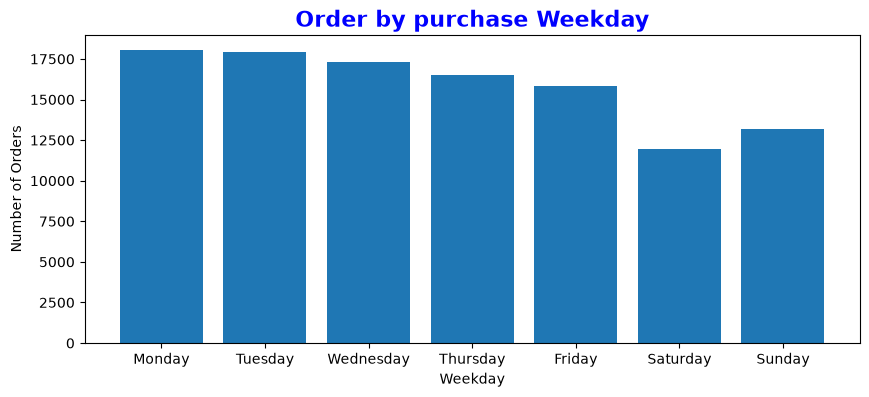

In [96]:
weekday_order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]

day_counts = ( data["purchase_weekday"].value_counts().reindex(weekday_order) )

plt.figure(figsize = (10,4))
plt.bar(day_counts.index, day_counts.values)
plt.xlabel("Weekday")
plt.ylabel("Number of Orders")
plt.title("Order by purchase Weekday", fontweight = "bold", fontsize = 16, color = "blue")
plt.show()

- Order volume peaks on Monday and Tuesday, making them the busiest shopping days of the week.
- Order volume gradually declines from Wednesday to Saturday, with Saturday recording the lowest number of orders.
- The weekly purchasing pattern highlights a clear variation in customer activity across different days of the week.

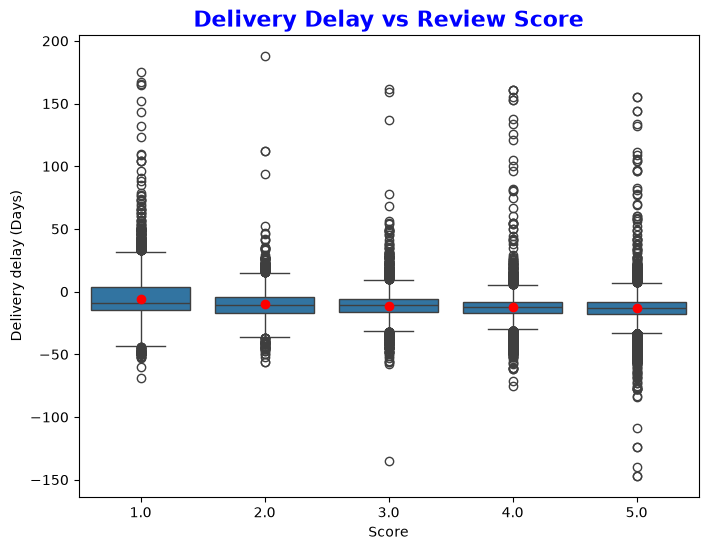

In [97]:
plt.figure(figsize= (8,6))
data_review = data[data["review_score"] != -1]
sns.boxplot(data = data_review, x = "review_score", y = "delivery_delay_days", showmeans = True, meanprops = {"marker": "o", 
            "markerfacecolor": "red",
            "markeredgecolor": "red"} )
plt.title("Delivery Delay vs Review Score", fontweight = "bold", fontsize = 16, color = "blue")
plt.xlabel("Score")
plt.ylabel("Delivery delay (Days)")
plt.show()

Delivery delays tend to be higher for lower review scores, although the distributions overlap across rating groups.

<Figure size 800x600 with 0 Axes>

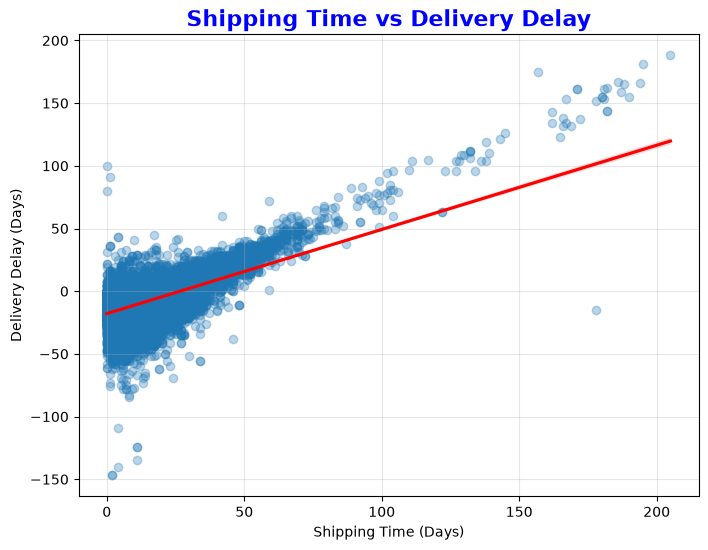

In [98]:
plt.figure(figsize = (8,6))
plt.figure(figsize=(8,6))
sns.regplot( data=data, x="shipping_days", y="delivery_delay_days", scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})

plt.title("Shipping Time vs Delivery Delay", fontweight = "bold", fontsize = 16, color = "blue")
plt.xlabel("Shipping Time (Days)")
plt.ylabel("Delivery Delay (Days)")
plt.grid(alpha=0.3)
plt.show()

Longer shipping times are associated with greater delivery delays, indicating a strong positive relationship between the two variables.

<Figure size 800x600 with 0 Axes>

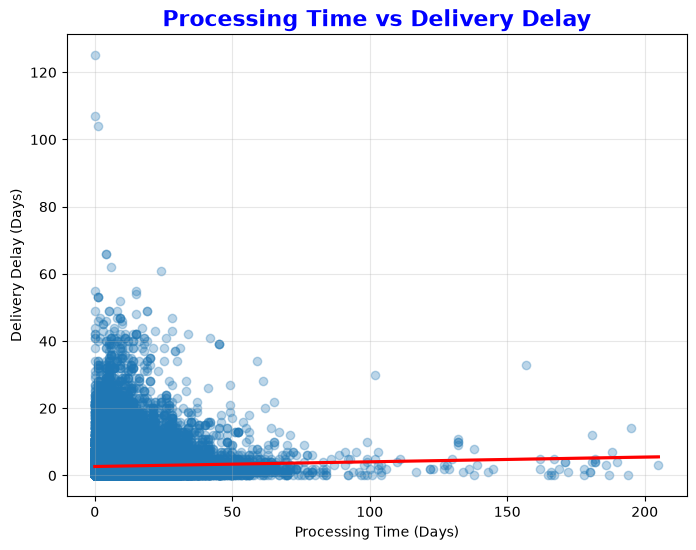

In [99]:
plt.figure(figsize = (8,6))
plt.figure(figsize=(8,6))
sns.regplot( data=data, x="shipping_days", y="processing_days", scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})

plt.title("Processing Time vs Delivery Delay", fontweight = "bold", fontsize = 16, color = "blue")
plt.xlabel("Processing Time (Days)")
plt.ylabel("Delivery Delay (Days)")
plt.grid(alpha=0.3)
plt.show()

The wide dispersion among longer processing times indicates that only a small number of orders experience exceptional processing delays.

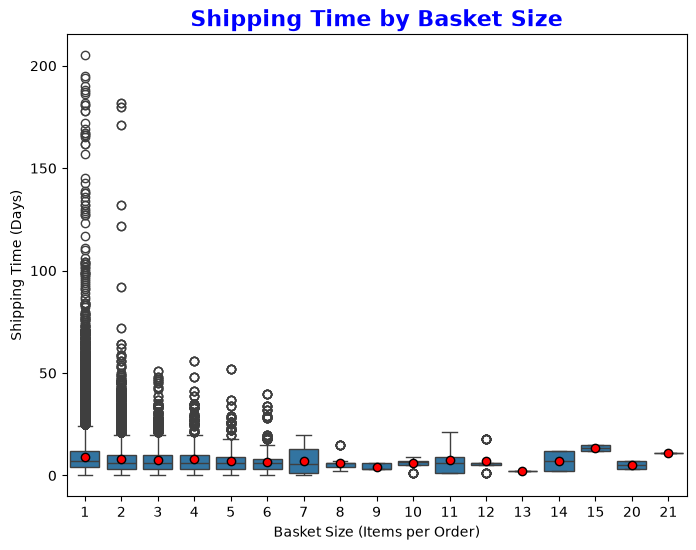

In [100]:
plt.figure(figsize=(8,6))

sns.boxplot( data=data, x="basket_size", y="shipping_days",showmeans=True,
         meanprops={ "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black" })

plt.title( "Shipping Time by Basket Size",fontsize=16, fontweight="bold", color="blue")
plt.xlabel("Basket Size (Items per Order)")
plt.ylabel("Shipping Time (Days)")

plt.show()

Shipping time is generally similar across basket sizes, with larger orders showing slightly more variation.

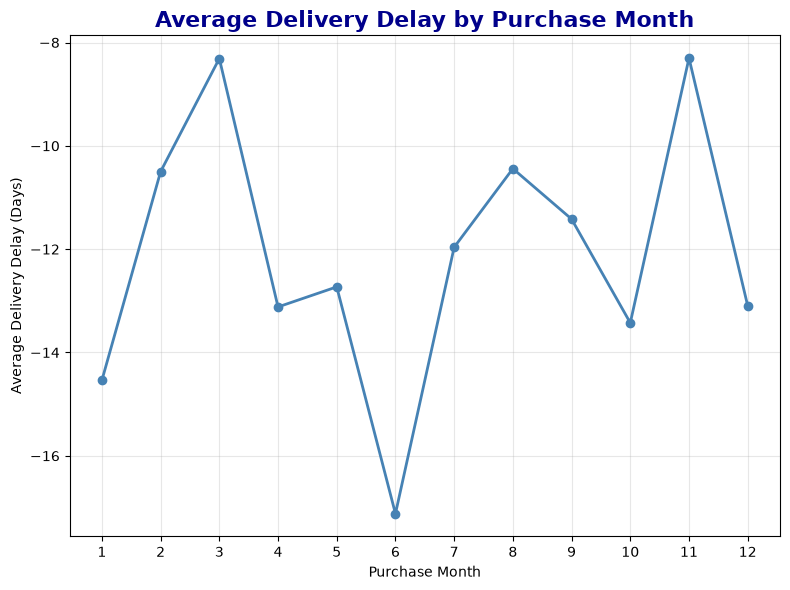

In [101]:
month_delay = ( data.groupby("purchase_month")["delivery_delay_days"].mean())

plt.figure(figsize=(8,6))
plt.plot( month_delay.index, month_delay.values, marker="o", linewidth=2, color="steelblue")

plt.title( "Average Delivery Delay by Purchase Month", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Purchase Month")
plt.ylabel("Average Delivery Delay (Days)")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Although delivery performance varies across months, the average delivery delay remains negative throughout the year, indicating that orders are generally delivered before the estimated date.

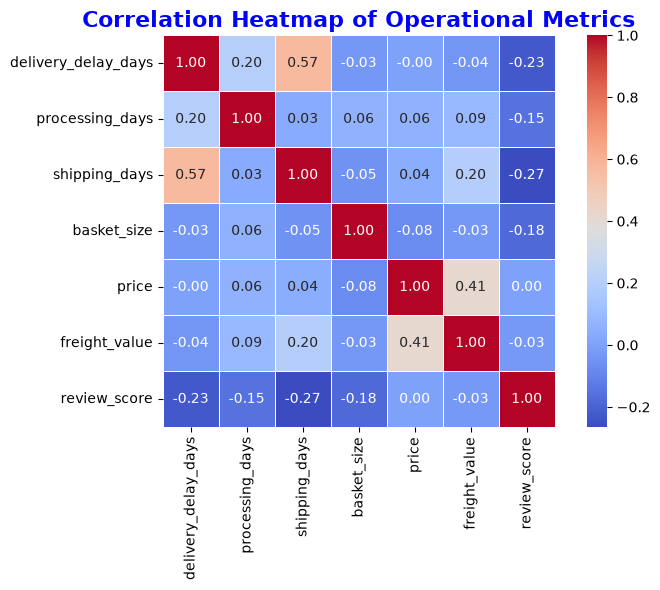

In [102]:
cols = [ "delivery_delay_days", "processing_days", "shipping_days", "basket_size","price","freight_value", "review_score"]

corr = data[cols].corr()
plt.figure(figsize=(8,6))

sns.heatmap( corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, square=True, cbar=True)

plt.title( "Correlation Heatmap of Operational Metrics", fontsize=16, fontweight="bold", color="blue")
plt.tight_layout()
plt.show()

The correlation analysis confirms the patterns observed in the bivariate analysis, with shipping time showing the strongest relationship with delivery delays.

KPI

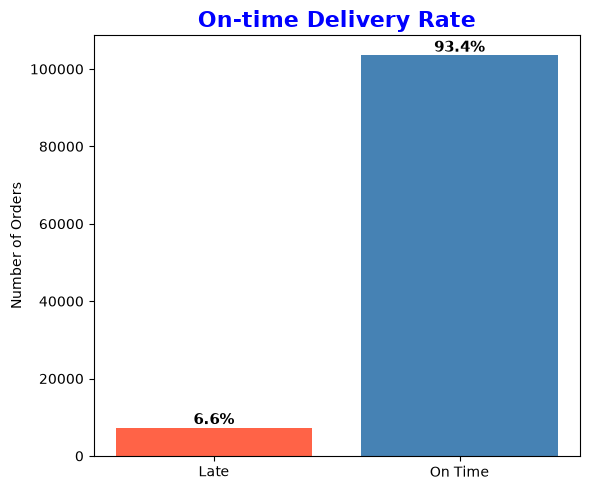

In [103]:
on_time = (data["on_time_flag"].value_counts().sort_index())
labels = ["Late", "On Time"]

plt.figure(figsize=(6,5))
bars = plt.bar( labels, on_time.values, color=["tomato", "steelblue"])

plt.title("On-time Delivery Rate", fontsize=16, fontweight="bold", color="blue")
plt.ylabel("Number of Orders")

total = on_time.sum()
for bar, value in zip(bars, on_time.values):
    plt.text( bar.get_x() + bar.get_width()/2, value, f"{value/total:.1%}",
        ha="center",va="bottom", fontsize=11,fontweight="bold" )

plt.tight_layout()
plt.show()

Approximately 93.4% of orders were delivered on or before the estimated delivery date, while only 6.6% experienced delays, indicating strong overall delivery performance.

Customer Impact Analysis

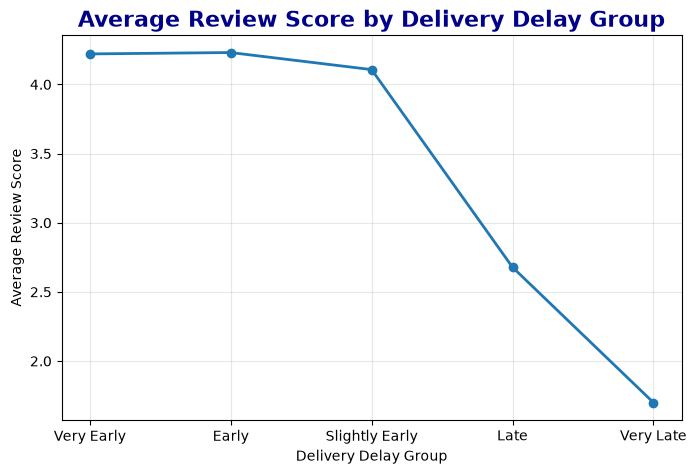

In [104]:
bins = [-float("inf"), -14, -7, 0, 7, float("inf")]
labels = ["Very Early", "Early", "Slightly Early", "Late", "Very Late"]

data_review = data[data["review_score"] != -1].copy()
data_review["delay_group"] = pd.cut(data_review["delivery_delay_days"], bins=bins, labels=labels)
avg_review = ( data_review.groupby("delay_group", observed=True)["review_score"].mean())

plt.figure(figsize=(8,5))
plt.plot(avg_review.index, avg_review.values, marker="o",linewidth=2)

plt.title("Average Review Score by Delivery Delay Group",fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Delivery Delay Group")
plt.ylabel("Average Review Score")
plt.grid(alpha=0.3)
plt.show()

Average review scores decline as delivery delays increase. Orders delivered early receive the highest ratings, while late deliveries are associated with substantially lower customer satisfaction.

KEY FINDINGS FROM EDA

- Most orders were delivered before the estimated delivery date, indicating stable overall delivery performance.
- Shipping time is the operational factor most strongly associated with delivery delays (r = 0.57), making carrier transit time the primary driver of late deliveries.
- Processing time has only a weak relationship with delivery delays (r = 0.20), suggesting that seller handling is not the main source of delays for most orders.
- Customer satisfaction decreases as delivery delays increase. Orders delivered early receive average review scores above 4, while very late deliveries receive ratings below 2.
- Basket size has minimal impact on shipping time and overall delivery performance, indicating that larger orders are not necessarily delivered more slowly.
- Price and freight value show a moderate positive correlation (r = 0.41), reflecting that higher-priced products generally incur higher shipping costs.

The exploratory analysis identified several operational patterns related to delivery performance. The following SQL analysis is conducted to validate these findings by calculating business KPIs and identifying the operational segments contributing most to delivery delays.